# Laboratorio 7 - Deep Learning

- Juan Solís - 23720
- Victor Pérez - 23731
- Diego Flores - 23714

## Task 1

### Task 1.1

Se descarga el dataset ETTh1 y se construye el pipeline de preprocesamiento sobre la variable objetivo `OT` (Oil Temperature). Se normaliza con z-score guardando `mu` y `sigma`, se divide en bloques temporales contiguos 60/20/20 (train/val/test) y se generan ventanas deslizantes de longitud $L = 96$ para los horizontes $H \in \{24, 48\}$, donde $X^{(t)} = (x_{t-L+1}, \dots, x_t)$ y $y^{(t)} = x_{t+H}$.

In [7]:
import urllib.request
import numpy as np
import torch

URL = ("https://raw.githubusercontent.com/zhouhaoyi/"
       "ETDataset/main/ETT-small/ETTh1.csv")
urllib.request.urlretrieve(URL, "ETTh1.csv")

data = np.genfromtxt("ETTh1.csv", delimiter=",", skip_header=1)
OT  = data[:, -1].astype(np.float32)   # Oil Temperature: columna objetivo
ALL = data[:, 1:].astype(np.float32)   # 7 variables (6 de carga + OT)

# a. Normalizacion z-score de OT
mu, sigma = OT.mean(), OT.std()
OT_norm =torch.tensor((OT - mu) / sigma)

# b. Split temporal contiguo 60/20/20
n =len(OT_norm)
n_tr, n_vl =int(0.6 * n), int(0.8 * n)
OT_train, OT_val, OT_test = OT_norm[:n_tr], OT_norm[n_tr:n_vl],OT_norm[n_vl:]

# c. Ventanas deslizantes
def make_windows( series, L, H ):
    N = len(series) - L - H + 1
    X = torch.stack([series[i:i + L] for i in range(N)])
    y = series[L - 1 + H : L - 1 + H + N]
    return X, y

L=96
X_tr_24, y_tr_24 = make_windows(OT_train, L, 24)
X_vl_24, y_vl_24 = make_windows(OT_val, L, 24)
X_te_24, y_te_24 = make_windows(OT_test, L, 24)
X_tr_48, y_tr_48 = make_windows(OT_train, L, 48)
X_vl_48, y_vl_48 = make_windows(OT_val, L, 48)
X_te_48, y_te_48 = make_windows(OT_test, L, 48)

print(f"mu={mu:.4f}, sigma={sigma:.4f}")
print(f"Train: {len(OT_train)}, Val: {len(OT_val)}, Test: {len(OT_test)}")
print(f"X_tr_24: {tuple(X_tr_24.shape)}, X_tr_48: {tuple(X_tr_48.shape)}")

mu=13.3247, sigma=8.5667
Train: 10452, Val: 3484, Test: 3484
X_tr_24: (10333, 96), X_tr_48: (10309, 96)


### Task 1.2

Se implementa la función de autocorrelación (ACF) con la fórmula

$$\rho(k) = \frac{\frac{1}{N-k}\sum_{t=k}^{N-1}(x_t - \bar{x})(x_{t-k} - \bar{x})}{\frac{1}{N}\sum_{t=0}^{N-1}(x_t - \bar{x})^2}$$

y se calcula sobre el conjunto de entrenamiento hasta el lag 96. Se grafica el correlograma con las bandas de confianza al 95% en $\pm 1.96/\sqrt{N}$ y se identifican los picos para analizar la periodicidad de la serie y la elección de $L = 96$.

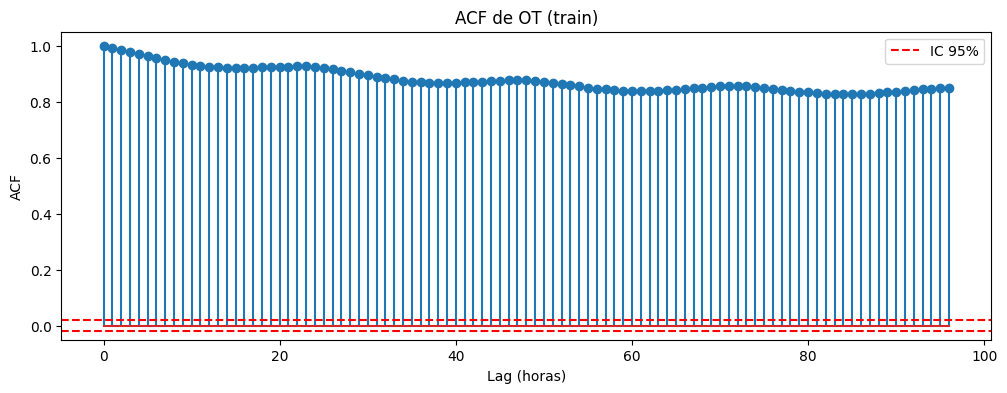

Picos locales: [(22, np.float32(0.9262)), (47, np.float32(0.877)), (72, np.float32(0.8572))]
rho(1) = 0.9923
rho(24) = 0.9250
rho(48) = 0.8763
rho(72) = 0.8572
rho(96) = 0.8489
IC 95%: +-0.0192


In [8]:
import matplotlib.pyplot as plt

# a. ACF manual segun la formula
def acf_manual(series, max_lag):
    N =len(series)
    d = series - series.mean()
    den =(d ** 2).sum() / N
    return np.array([(d[k:] * d[:N - k]).sum() / (N - k) / den for k in range(max_lag + 1)])

x_tr= OT_train.numpy()
acf_vals = acf_manual(x_tr, 96)
ci =1.96 / np.sqrt(len(x_tr))

plt.figure(figsize=(12, 4))
plt.stem(range(97), acf_vals)
plt.axhline(ci, color="r", linestyle="--", label="IC 95%")
plt.axhline(-ci, color="r", linestyle="--")
plt.xlabel("Lag (horas)")
plt.ylabel("ACF")
plt.title("ACF de OT (train)")
plt.legend()
plt.show()

# a. Picos locales de la ACF (despues del lag 0)
peaks =[k for k in range(1, 96) if acf_vals[k] > acf_vals[k - 1] and acf_vals[k] > acf_vals[k + 1]]
print( "Picos locales:", [ ( k, round( acf_vals[k],4 )) for k in peaks ] )

# b. Valores de la ACF en lags clave para justificar L = 96
for k in [1, 24, 48, 72, 96]:
    print(f"rho({k}) = {acf_vals[k]:.4f}")
print(f"IC 95%: +-{ci:.4f}")

In [9]:
# Ejecute esta celda para verificar su implementacion
_ok = True

# V1: split temporal correcto
assert len(OT_train) + len(OT_val) + len(OT_test) == len(OT_norm), \
    "Los splits no cubren toda la serie"
assert OT_train[-1] != OT_val[0], \
    "El ultimo valor de train no debe ser el primero de val"

# V2: ventanas correctas
assert X_tr_24.shape[1] == 96, f"Ventana incorrecta: {X_tr_24.shape[1]}"
assert y_tr_24.shape[0] == X_tr_24.shape[0], "X e y tienen distinto numero de ejemplos"

# V3: ACF en lag 24 (estacionalidad diaria esperada)
acf_lag24 = acf_manual(OT_train.numpy(), 48)[24]
assert 0.875 < acf_lag24 < 0.975, \
    f"ACF lag 24 fuera de rango: {acf_lag24:.4f} (esperado en [0.875, 0.975])"

# V4: baseline naive
naive_mae = torch.abs(y_vl_24 - X_vl_24[:, -1]).mean().item()
assert 0.15 < naive_mae < 0.25, \
    f"Naive MAE fuera de rango: {naive_mae:.4f} (esperado en [0.15, 0.25])"

print(f"Task 1: CORRECTO (ACF lag24={acf_lag24:.4f}, naive_mae={naive_mae:.4f})")

Task 1: CORRECTO (ACF lag24=0.9250, naive_mae=0.1996)
